## Exploring Cross Infection between two variants
**Author:** Karen Guzman

**Description:** Exploring a two-variant SIR model with cross-infection and permanent same-variant immunity. Nobody is infected by the same immunity twice. This is a 9-compartment model made up of S, I1, I2, I12, I21, R1, R2, R12, R21.


**Date:** 6/19/2026

#### Scenarios

**Scenario 1:** Emergence of variant 2 long after variant 1

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import cross_infection_1 as ci
importlib.reload(ci)

<module 'cross_infection_1' from '/mnt/c/Users/krngz/OneDrive/UVA/Summer 2026/C4GC/epidemic-drivers-through-machine-learning/notebooks/../models/cross_infection_1.py'>

R0 of variant 1: 1.27
R0 of variant 2: 7.08
R0 of variant 2 at emergence: 7.08
Peak of variant 1 (I1+I21): 52.8 at t=10.5
Peak of variant 2 (I2+I12): 582.3 at t=162.3

Never infected: 0
Infected by variant 1 only: 0
Infected by variant 2 only: 531
First variant 1, then variant 2: 468
First variant 2, then variant 1: 0
Total: 1000
Figure saved to figures/cross_inf_1_scenario_1.png


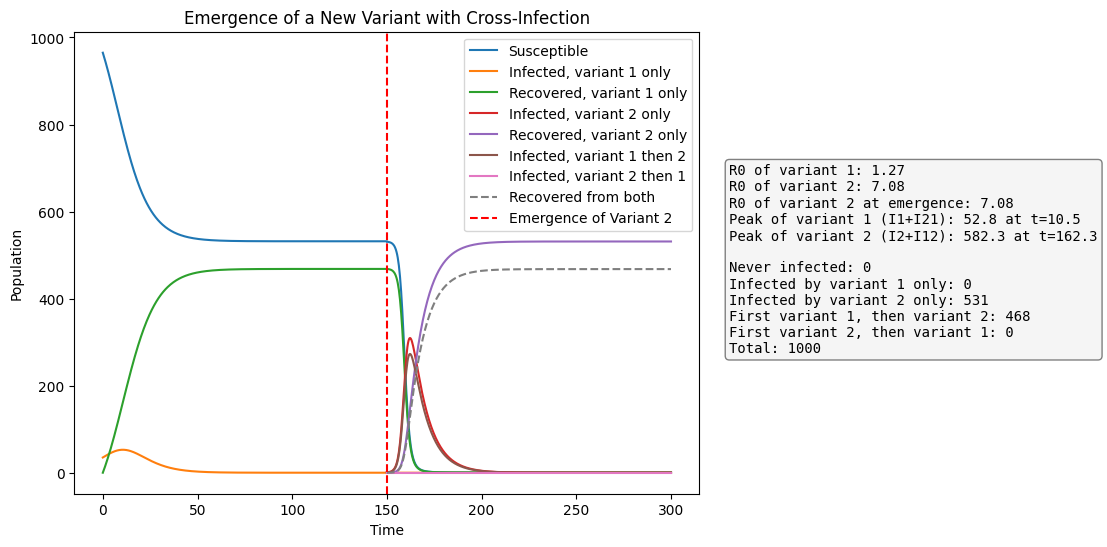

In [2]:
#where variant 2 emerges and takes over
params = [0.42, 0.85, 0.33, 0.12, 1, 1] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0, 0, 0, 0, 0] # 965 susceptible, 35 infected with strain 1
t, y = ci.simulate_cross_infection(params, y0, t_emerge=150)

ci.plot_cross_infection(t, y, params, filename="cross_inf_1_scenario_1.png")

We simulate a scenario using the same parameters from the new emergence (full cross-immunity). Variant 1 ($R_0 = 1.27$) still produces a wave peak of 52.8 at $t = 10$. Variant 2's effective $R_0$ remains the same as its intrinsic value (7.08) at $T = 150$. Since the 468 people that recovered from variant 1 are not protected from variant 2 anymore, variant 2 emerges into the whole population as fair game. The total for "Variant 1 only" plummets to 0 because everyone who got it also got variant 2 later on.

If plotting cross-infection reports still infected at the end of the run, the variants haven't burned out yet and t_total could be increased to fully capture the epidemic

**Scenario 2:** Variant 1 and 2 circulating at the same time

R0 of variant 1: 1.27
R0 of variant 2: 7.08
R0 of variant 2 at emergence: 6.71
Peak of variant 1 (I1+I21): 52.7 at t=10.4
Peak of variant 2 (I2+I12): 561.2 at t=20.9

Never infected: 1
Infected by variant 1 only: 1
Infected by variant 2 only: 653
First variant 1, then variant 2: 314
First variant 2, then variant 1: 32
Total: 1000
Figure saved to figures/cross_inf_1_scenario_2.png


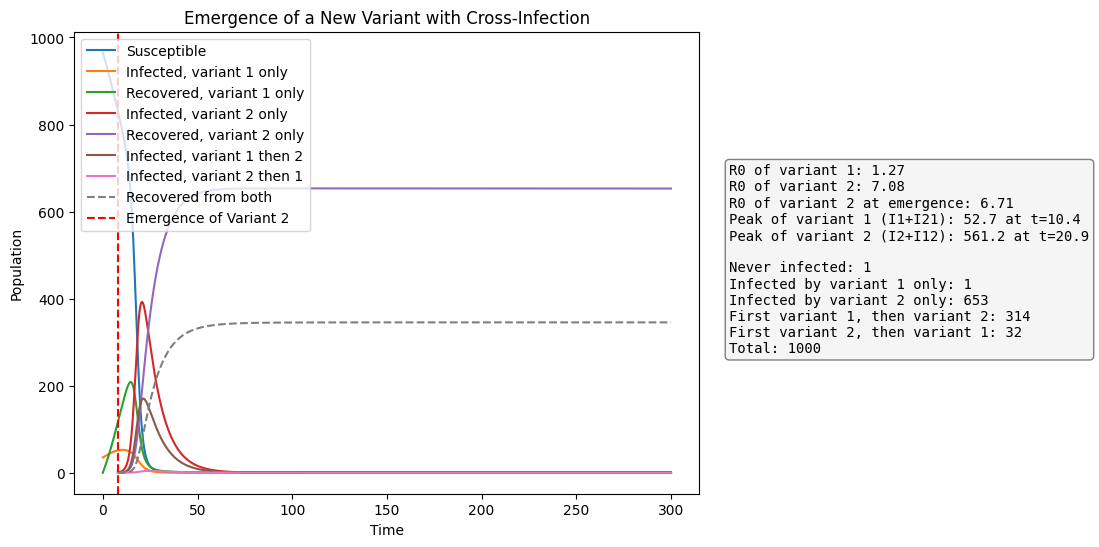

In [3]:
#same params as scenario 1, changing emergence time to 8 days
params = [0.42, 0.85, 0.33, 0.12, 1, 1] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0, 0, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ci.simulate_cross_infection(params, y0, t_emerge=8)

ci.plot_cross_infection(t, y, params, filename="cross_inf_1_scenario_2.png")

Here, variant 1 and 2 circulate at the same time with the same parameters and emergence time as scenario 2 of new emergence. Variant 1's peak remains about the same (52.8 at $t = 10$).  Since variant 2 emerges while variant 1 is at its peak, it removes the competition from the full cross-immunity new emergence model. Variant 2's effective $R_0$ decreases a bit ($7.08 \rightarrow 6.71$), reflecting the people that are momentarily still infected by variant 1. 314 people who got variant 1 first then got variant 2; only 1 person got variant 1 alone. We see a large increase in individuals who only contracted variant 2 ($531 \rightarrow 653$) compared to scenario 1. Previously, no individuals were infected by variant 2 then 1, now, we have a total of 32 people in this category.